In [1]:
from ezfalcon.tools import TruncatedNFWPotential
from galpy.potential import NFWPotential
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rho0 = 1.0
a = 1.5
amp = rho0 * 4 * np.pi * a**3
nfwpot = NFWPotential(amp = 0.1, a = a)
rcutoff = 3. #nfwpot.rvir()
truncNFW = TruncatedNFWPotential(amp=0.1, a=a, rc=rcutoff)
truncNFW.turn_physical_on(ro=8., vo=220.)
mtotal = truncNFW.mass(rcutoff*4)

In [ ]:
from ezfalcon.tools import galpysampler
from ezfalcon.simulation import Sim

pos, vel, masses = galpysampler(n=5000, m_total=mtotal, pot=truncNFW, df_args={'rmax':rcutoff*4})
halo = Sim()
halo.add_particles('halo', pos=pos, vel=vel, mass=masses)
halo.run(4., dt=0.0005, dt_out=0.01, eps=0.01, theta=0.5)

TypeError: galpysampler() got an unexpected keyword argument 'df_args'

In [ ]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim(-rcutoff*8, rcutoff*8)
ax.set_ylim(-rcutoff*8, rcutoff*8)
scatter = ax.scatter(halo.x(0), halo.y(0), s=1, alpha=0.5)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

nframes = int(np.round(1.0 / 0.01))//5 + 1

def animate_frame(frame):
    frame *= 5
    xdata = halo.x(frame)
    ydata = halo.y(frame)
    scatter.set_offsets(np.column_stack((xdata, ydata)))
    time_text.set_text(f't = {frame * 0.01:.2f}')
    return scatter, time_text

anim = animation.FuncAnimation(fig, animate_frame, frames=nframes, interval=100, blit=True)
HTML(anim.to_jshtml())

In [3]:
from scipy.interpolate import PchipInterpolator
from astropy import units as u
n = 5000
mpt = mtotal / n
print(f'Mass per particle: {mpt:.2e}')
# Build inverse CDF directly from vmomentdensity-derived enclosed mass.
Rs = np.logspace(-5, np.log10(rcutoff*8), 10000) * u.kpc
M = truncNFW.mass(R = Rs)
F = M / M[-1]
valid = np.isfinite(F)
F = F[valid]
R_vals = Rs.to_value(u.kpc)[valid]

# Keep only strictly increasing CDF points for interpolation stability.
mask = np.concatenate(([True], np.diff(F) > 1e-14))
if np.sum(mask) < 2:
    raise ValueError("CDF is not strictly increasing; rerun Cell 8 or adjust grid/smoothing.")
F_strict = F[mask]
R_strict = R_vals[mask]
Finv = PchipInterpolator(F_strict, R_strict, extrapolate=False)

# Sample radii.

u_rand = np.random.random(n)
rsamp = Finv(u_rand)

# Isotropic angles -> Cartesian
cos_th = 2 * np.random.random(n) - 1
phi = 2 * np.pi * np.random.random(n)
sin_th = np.sqrt(1 - cos_th**2)
x = rsamp * sin_th * np.cos(phi)
y = rsamp * sin_th * np.sin(phi)
z = rsamp * cos_th

Rsamp = np.sqrt(x**2 + y**2)

Mass per particle: 6.87e+05


(np.float64(-25.873567234083126),
 np.float64(25.291121703467496),
 np.float64(-25.79548702223787),
 np.float64(25.280571011641875))

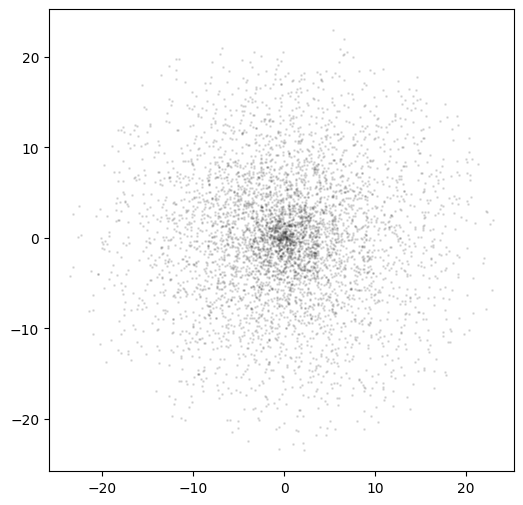

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, c='k', s=1, alpha=0.1)
plt.axis('equal')

(array([0.00224913, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00224913, 0.00224913, 0.00224913, 0.01124566,
        0.01349479, 0.02474045, 0.01349479, 0.04048437, 0.05397916,
        0.07197222, 0.10795832, 0.13044964, 0.17093401, 0.30138365,
        0.41608937, 0.53079509, 0.59601991, 0.73321695, 1.04134799,
        1.19878722, 1.3179912 , 1.49117434, 1.50242   , 1.46868302]),
 array([-1.28769879, -1.19877559, -1.10985238, -1.02092918, -0.93200597,
        -0.84308277, -0.75415957, -0.66523636, -0.57631316, -0.48738996,
        -0.39846675, -0.30954355, -0.22062034, -0.13169714, -0.04277394,
         0.04614927,  0.13507247,  0.22399568,  0.31291888,  0.40184208,
         0.49076529,  0.57968849,  0.6686117 ,  0.7575349 ,  0.8464581 ,
         0.93538131,  1.02430451,  1.11322772,  1.20215092,  1.29107412,
         1.37999733]),
 <BarContainer object of 30 artists>)

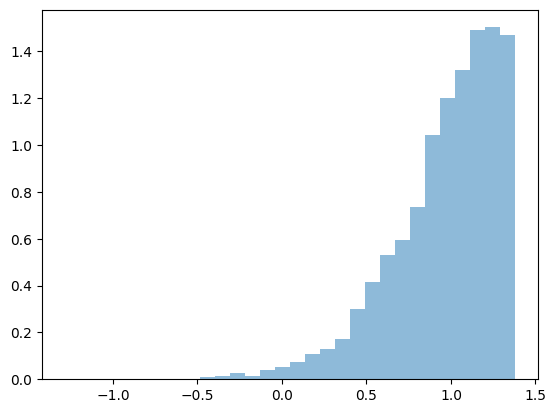

In [5]:
plt.hist(np.log10(rsamp), bins=30, density=True, alpha=0.5, label='Sampled')

<>:18: SyntaxWarning: invalid escape sequence '\o'

<>:18: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_2752236/1814054052.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Density (M$_\odot$ kpc$^{-3}$)')



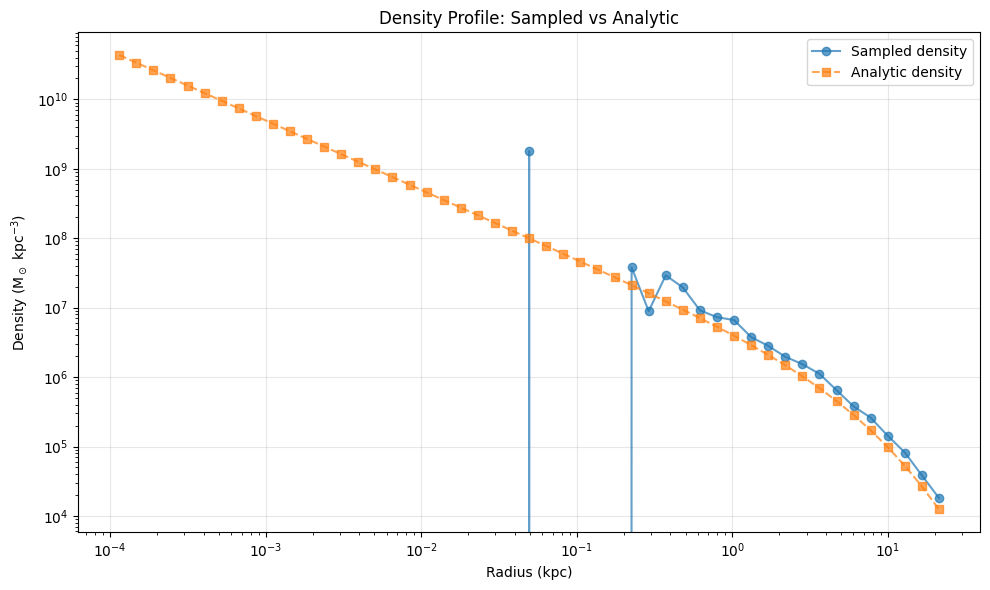

In [6]:
# Calculate the density profile from sampled points
r_bins = np.logspace(-4, np.log10(rcutoff*8), 50)
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
hist, _ = np.histogram(rsamp, bins=r_bins)
# Normalize by bin volume (4*pi*r^2*dr)
dr = np.diff(r_bins)
bin_volumes = 4 * np.pi * r_bin_centers**2 * dr
density_sampled = hist * mpt / bin_volumes

# Calculate analytic density profile from potential
density_analytic = truncNFW.dens(r_bin_centers * u.kpc, z=0., quantity=True).to(u.Msun/u.kpc**3).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, density_sampled, 'o-', label='Sampled density', alpha=0.7)
plt.loglog(r_bin_centers, density_analytic, 's--', label='Analytic density', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M$_\odot$ kpc$^{-3}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Density Profile: Sampled vs Analytic')
plt.tight_layout()

<>:14: SyntaxWarning: invalid escape sequence '\o'

<>:14: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_2752236/2165063499.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Enclosed Mass (M$_\odot$)')



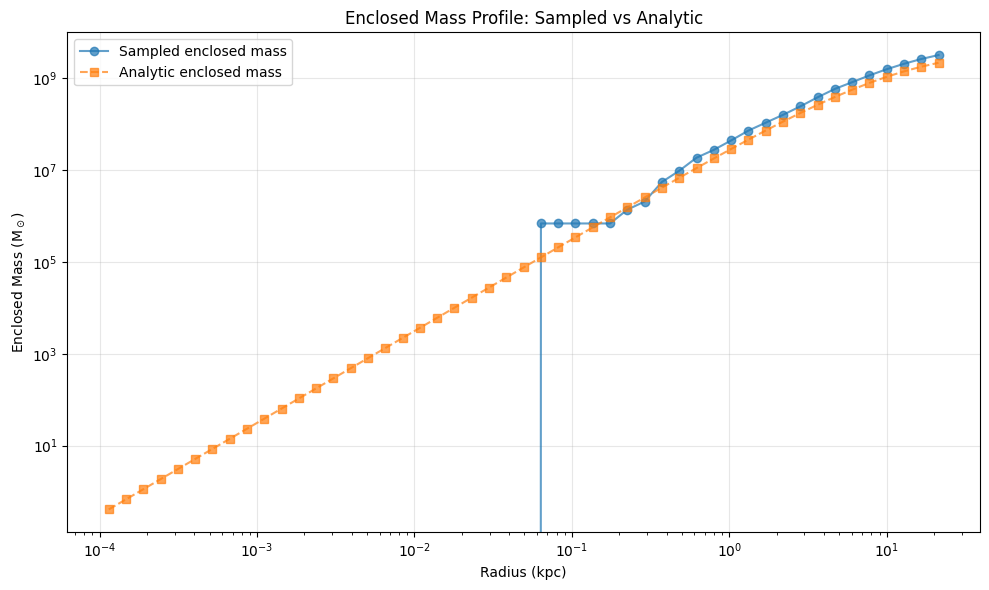

In [7]:
# Calculate enclosed mass from sampled points
M_sampled = np.zeros_like(r_bin_centers)
for i, r in enumerate(r_bin_centers):
    M_sampled[i] = np.sum(rsamp <= r) * mpt  # Normalize by total mass

# Calculate analytic enclosed mass
M_analytic = truncNFW.mass(r_bin_centers * u.kpc)#.to(u.Msun).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, M_sampled, 'o-', label='Sampled enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_analytic, 's--', label='Analytic enclosed mass', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Enclosed Mass (M$_\odot$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Enclosed Mass Profile: Sampled vs Analytic')
plt.tight_layout()
plt.show()

## velocity samples

In [8]:
from galpy.df import eddingtondf 

df = eddingtondf(pot=truncNFW,rmax=rcutoff*4)

#osamps = [df.sample(R=_R*u.kpc, z=_z*u.kpc, phi=_phi*u.rad) for _R, _z, _phi in zip(Rsamp, z, phi)]

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/tools/galpy_tools.py:393: RuntimeWarning: invalid value encountered in scalar divide
  return -(self._F(r) / r + self._G(r))

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/SphericalPotential.py:58: RuntimeWarning: invalid value encountered in scalar multiply
  return self._rforce(r, t=t) * R / r



In [9]:
osamps = df.sample(n=n)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:183: RuntimeWarning: invalid value encountered in sqrt
  / numpy.sqrt(_evaluatePotentials(pot, r, 0) - E)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:139: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrate.quad(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:139: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance fr

In [10]:
#truncNFW.turn_physical_off()

In [11]:
Es = np.linspace(truncNFW(1e-10, 0., 0.), truncNFW(100., 0.,0.))

/tmp/ipykernel_2752236/3778257941.py:2: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')

[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]


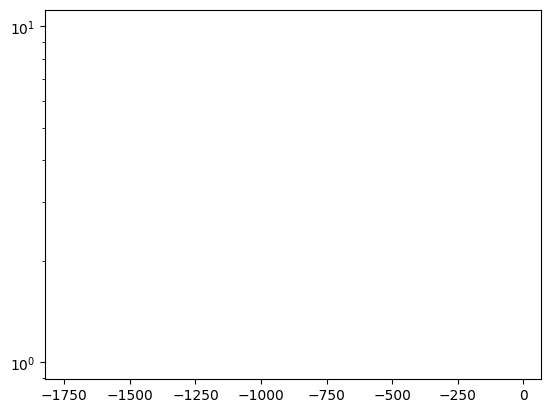

In [12]:
plt.plot(Es, df.fE(Es))
plt.yscale('log')
print(df.fE(Es))

In [13]:
from ezfalcon.tools import galpy_orbit_to_ezfalcon
pvms = np.array([np.array(galpy_orbit_to_ezfalcon(o)) for o in osamps])

# Evolve halo

In [14]:
pos = pvms[:, 0].reshape(-1, 3) 
vel = pvms[:, 1].reshape(-1, 3)
masses = np.full(len(pos), mpt)

In [15]:
np.cumsum(np.linalg.norm(pos, axis=-1))

array([1.16026423e+01, 3.10232454e+01, 8.65399966e+01, ...,
       1.02042026e+05, 1.02056852e+05, 1.02076189e+05], shape=(5000,))

In [16]:
from ezfalcon.simulation import Sim
from ezfalcon.tools import galpy_orbit_to_ezfalcon
pos, vel = galpy_orbit_to_ezfalcon(osamps)
# pos, vel = pos*8, vel * 220
masses = np.full(len(pos), mpt)
halo = Sim()
halo.add_particles('halo', pos=pos, vel=vel, mass=masses)

<>:14: SyntaxWarning: invalid escape sequence '\o'

<>:14: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_2752236/2165063499.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Enclosed Mass (M$_\odot$)')



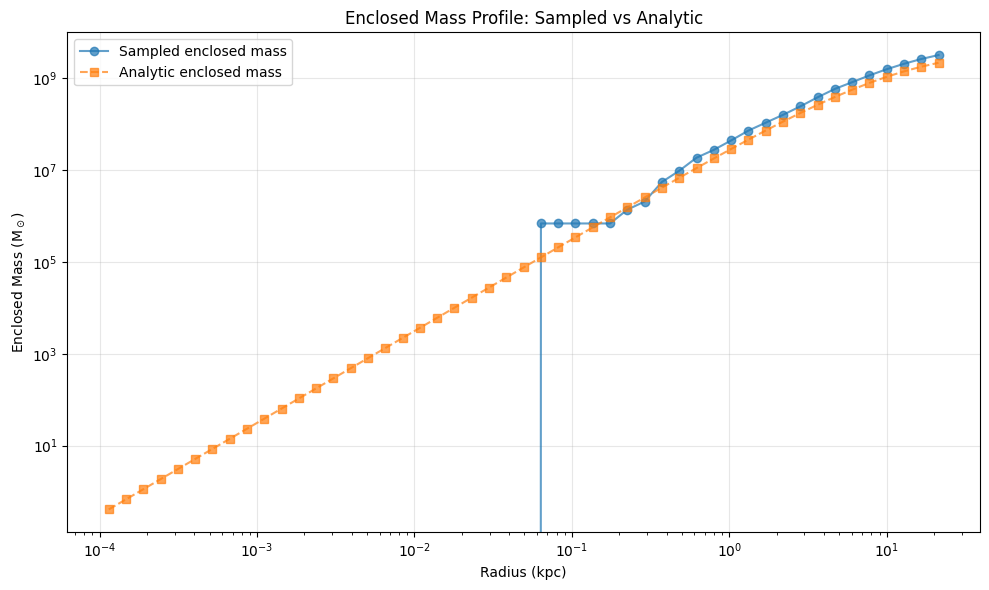

In [17]:
# Calculate enclosed mass from sampled points
M_sampled = np.zeros_like(r_bin_centers)
for i, r in enumerate(r_bin_centers):
    M_sampled[i] = np.sum(rsamp <= r) * mpt  # Normalize by total mass

# Calculate analytic enclosed mass
M_analytic = truncNFW.mass(r_bin_centers * u.kpc)#.to(u.Msun).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, M_sampled, 'o-', label='Sampled enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_analytic, 's--', label='Analytic enclosed mass', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Enclosed Mass (M$_\odot$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Enclosed Mass Profile: Sampled vs Analytic')
plt.tight_layout()
plt.show()

In [18]:
halo.run(2., dt=0.0005, dt_out=0.01, eps=0.01, theta=0.5)

100%|██████████| 4000/4000 [00:55<00:00, 72.61it/s]


/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/tools/galpy_tools.py:396: RuntimeWarning: invalid value encountered in divide
  return -self._F(r) / (r * r)



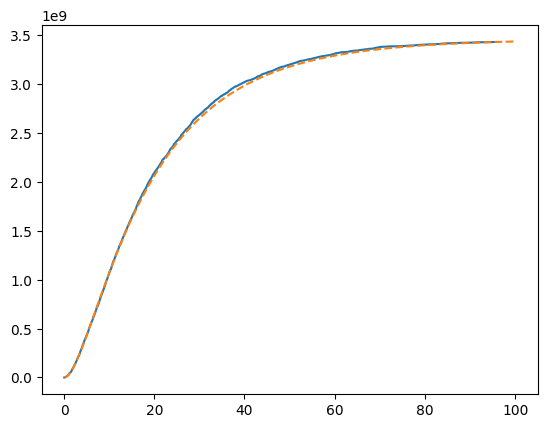

In [19]:
osamps.turn_physical_on()
rs = np.linspace(0, 100, 1000) * u.kpc
plt.plot(np.sort(osamps.r()), np.linspace(0, 1, n)*mtotal)
truncNFW.turn_physical_on()
plt.plot(rs, truncNFW.mass(rs), ls='--')

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1050: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



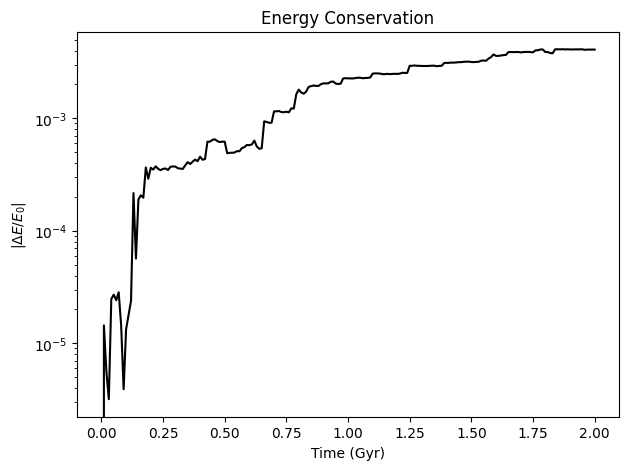

In [20]:
halo.plot_energy_diagnostic()

(np.float64(-99.33033227230908),
 np.float64(99.03510696871663),
 np.float64(-95.19433878515473),
 np.float64(92.37339249545522))

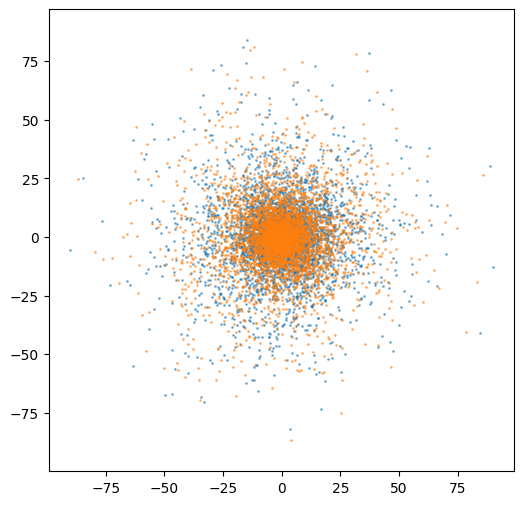

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(halo.x(0), halo.y(0), s=1, alpha=0.5)
plt.scatter(halo.x(-1), halo.y(-1), s=1, alpha=0.5)
plt.axis('equal')

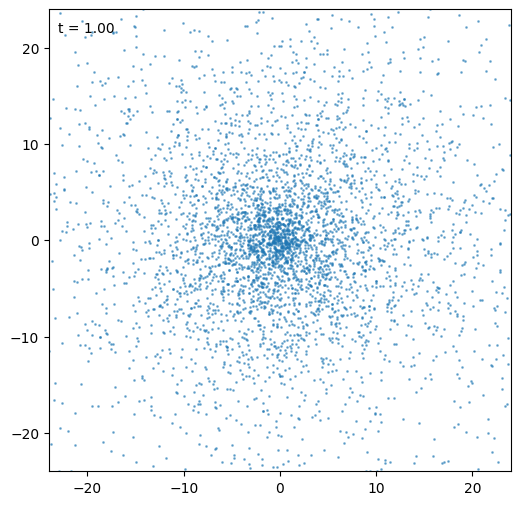

In [24]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim(-rcutoff*8, rcutoff*8)
ax.set_ylim(-rcutoff*8, rcutoff*8)
scatter = ax.scatter(halo.x(0), halo.y(0), s=1, alpha=0.5)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

nframes = int(np.round(1.0 / 0.01))//5 + 1

def animate_frame(frame):
    frame *= 5
    xdata = halo.x(frame)
    ydata = halo.y(frame)
    scatter.set_offsets(np.column_stack((xdata, ydata)))
    time_text.set_text(f't = {frame * 0.01:.2f}')
    return scatter, time_text

anim = animation.FuncAnimation(fig, animate_frame, frames=nframes, interval=100, blit=True)
HTML(anim.to_jshtml())

(array([0.0114, 0.0318, 0.0556, 0.087 , 0.116 , 0.1526, 0.1904, 0.2242,
        0.257 , 0.2906, 0.329 , 0.3644, 0.402 , 0.4326, 0.4626, 0.4914,
        0.5168, 0.548 , 0.5762, 0.5992, 0.6224, 0.6472, 0.6724, 0.6954,
        0.7184, 0.739 , 0.7574, 0.778 , 0.793 , 0.8106, 0.8272, 0.8394,
        0.8534, 0.8672, 0.8812, 0.8932, 0.9058, 0.9164, 0.9288, 0.9378,
        0.946 , 0.9536, 0.9618, 0.9694, 0.9764, 0.984 , 0.9888, 0.9922,
        0.9962, 1.    ]),
 array([ 0.05014006,  0.52609842,  1.00205679,  1.47801516,  1.95397352,
         2.42993189,  2.90589025,  3.38184862,  3.85780698,  4.33376535,
         4.80972371,  5.28568208,  5.76164044,  6.23759881,  6.71355717,
         7.18951554,  7.6654739 ,  8.14143227,  8.61739063,  9.093349  ,
         9.56930736, 10.04526573, 10.52122409, 10.99718246, 11.47314082,
        11.94909919, 12.42505755, 12.90101592, 13.37697428, 13.85293265,
        14.32889101, 14.80484938, 15.28080774, 15.75676611, 16.23272447,
        16.70868284, 17.1846412

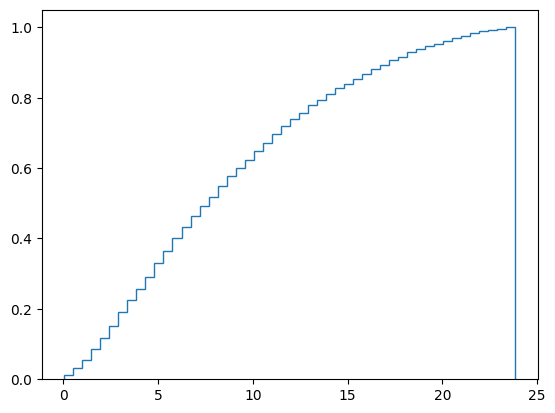

In [91]:
plt.hist(Rsamp, bins=50, density=True, cumulative=True, histtype='step', label='Binned CDF')